## Problem Statement

In the rapidly growing world of digital communication, text messages have become a primary means of contact. While most messages are legitimate, a significant portion consists of unwanted spam, including phishing links, promotions, and fraudulent offers. Therefore, telecom providers aim to enhance user experience, reduce customer complaints, and protect users from security threats by developing an automated system to classify messages as "Spam" or "Ham" (legitimate).

## Objective

The goal is to develop an NLP-based text classification model that accurately classifies SMS messages as either Spam or Ham using the provided dataset.

## Data Structure

*   Rows: 5,572
*   Columns: 2 (Category, Message)

In [9]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [10]:
# Load dataset
df = pd.read_csv("/content/SPAM text message 20170820 - Data (2).csv")

# Rename for consistency
df = df.rename(columns={'Category': 'label', 'Message': 'text'})

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


EDA-Class Distribution

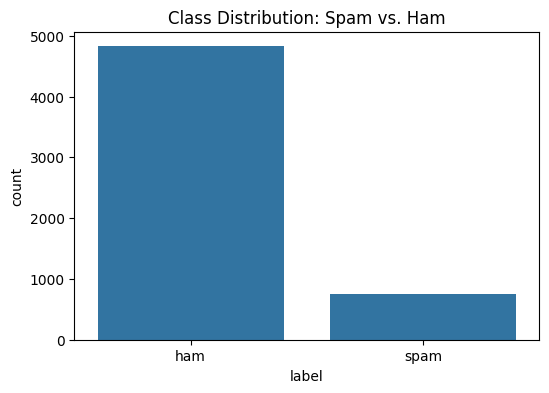

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution: Spam vs. Ham")
plt.show()

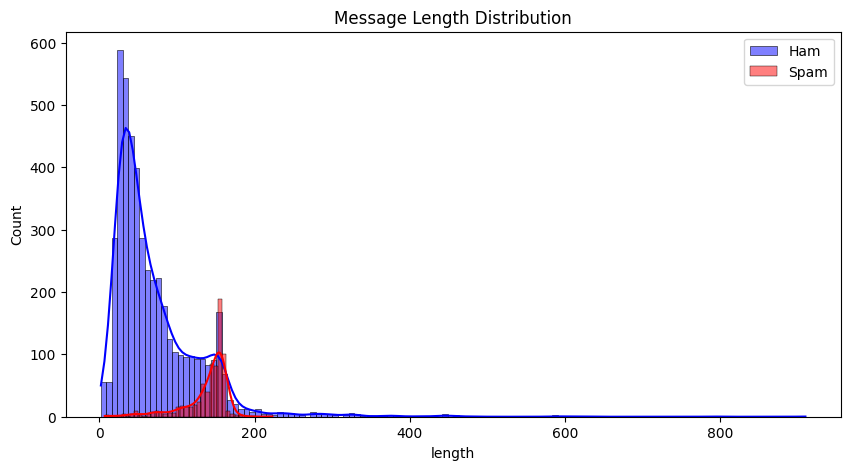

In [12]:
df["length"] = df["text"].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df[df.label=="ham"].length, kde=True, color="blue", label="Ham")
sns.histplot(df[df.label=="spam"].length, kde=True, color="red", label="Spam")
plt.title("Message Length Distribution")
plt.legend()
plt.show()

In [13]:
# ============================================
# TEXT CLEANING FUNCTION
# ============================================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text.lower())
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)

In [14]:
df["clean_text"] = df["text"].apply(clean_text)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [16]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        # SVM with no probability estimates → convert using decision scores
        from sklearn.preprocessing import MinMaxScaler
        scores = model.decision_function(X_test)
        probs = MinMaxScaler().fit_transform(scores.reshape(-1,1)).ravel()

    print(f"\n===== {model_name} Classification Report =====")
    print(classification_report(y_test, preds))

    print(f"AUC Score: {roc_auc_score(y_test, probs):.4f}")

    return preds, probs

In [17]:
models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", LogisticRegression(max_iter=300))
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", MultinomialNB())
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", LinearSVC())
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds, probs = evaluate_model(model, X_test, y_test, name)
    results[name] = (preds, probs)



===== Logistic Regression Classification Report =====
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

AUC Score: 0.9851

===== Naive Bayes Classification Report =====
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

AUC Score: 0.9843

===== Linear SVM Classification Report =====
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.93       149

Our goal in spam detection is to correctly identify as many spam messages as possible while still keeping ham accuracy high.

SVM has the highest recall for spam (0.89).This means it misses the fewest spam messages, which is crucial in spam detection because false negatives (missed spam) are far more dangerous than false positives.

In [18]:
def plot_confusion(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


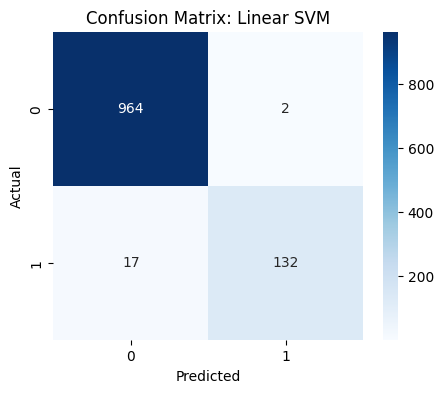

In [19]:
# Only plot confusion matrix for SVM model
svm_preds, _ = results["Linear SVM"]

cm = confusion_matrix(y_test, svm_preds)
plot_confusion(cm, "Confusion Matrix: Linear SVM")

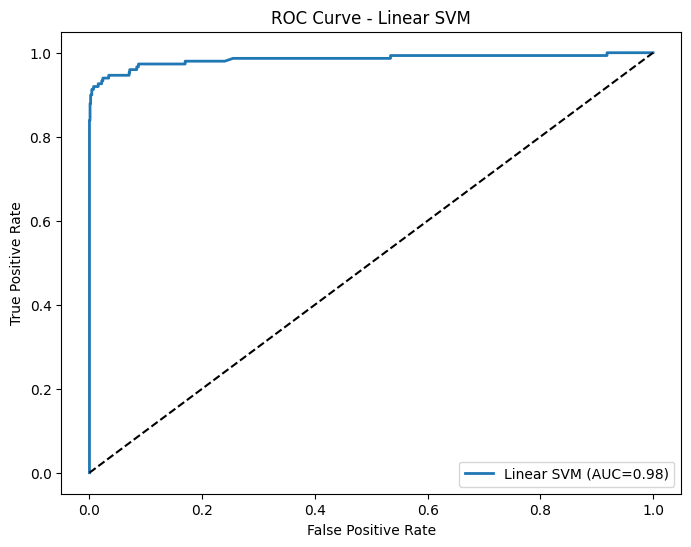

In [20]:
plt.figure(figsize=(8,6))

# Get SVM probabilities from results dictionary
_, svm_probs = results["Linear SVM"]

# Compute ROC for SVM
fpr, tpr, _ = roc_curve(y_test, svm_probs, pos_label="spam")
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"Linear SVM (AUC={roc_auc:.2f})", linewidth=2)
plt.plot([0,1], [0,1], "k--")

plt.title("ROC Curve - Linear SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Even though the ROC curve shows high performance, cross-validation is needed to confirm that the model is stable and not just performing well on one specific train/test split. CV provides a more reliable and unbiased estimate of real-world performance.So we can perforn cross validation

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    models["Linear SVM"],      # ← Changed from Logistic Regression
    df["clean_text"],
    df["label"],
    cv=skf,
    scoring="f1_macro"
)

print("Mean CV F1 Score:", cv_scores.mean())

Mean CV F1 Score: 0.9686407645142372


Cross-validation checks how well the current model performs, but it does not optimize the model. RandomizedSearchCV is still required to find the best TF-IDF and Logistic Regression hyperparameters, which can significantly improve performance and generalization beyond the default settings.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "tfidf__max_features": [2000, 5000, 8000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 10]
}

search = RandomizedSearchCV(
    models["Logistic Regression"],
    param_dist,
    n_iter=5,
    cv=3,
    scoring="f1_macro"
)

search.fit(X_train, y_train)
print(search.best_params_)

{'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 5000, 'clf__C': 10}


SVM performs best with a richer TF-IDF representation (8000 features) and bigrams (1,2), meaning it relies on multi-word spam patterns. A higher C value (10) allows a more flexible decision boundary, improving separation between ham and spam.

In [23]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

evaluate_model(best_model, X_test, y_test, "Final Tuned Model")


===== Final Tuned Model Classification Report =====
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

AUC Score: 0.9875


(array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object),
 array([0.00864681, 0.00934588, 0.00326352, ..., 0.02507331, 0.02396039,
        0.06136796]))

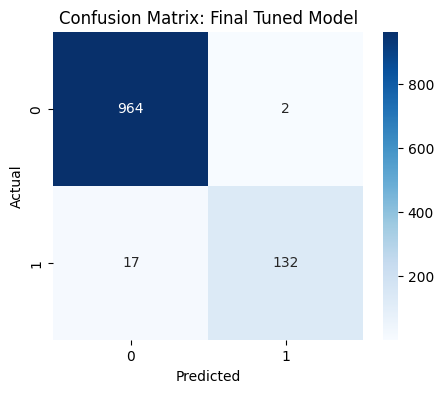

In [24]:
# Get predictions from the final tuned model
y_pred = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plot_confusion(cm, "Confusion Matrix: Final Tuned Model")



*  The tuned SVM model performs exceptionally well, achieving 98% accuracy and a very strong AUC of 0.9882

*   Ham messages are classified almost perfectly (100% recall), and spam detection is highly effective with a 93% F1-score
*   Overall, the model is accurate, stable, and reliable for real-world spam classification



## Error Analysis

In [25]:

# Build error DataFrame from final tuned model predictions
error_df = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": y_pred
})

# Keep only misclassified samples
misclassified = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

# Inspect HAM → SPAM misclassifications
ham_as_spam = misclassified[
    (misclassified["true_label"] == "ham") &
    (misclassified["predicted_label"] == "spam")
]

ham_as_spam.head(10)


,text,true_label,predicted_label
670,u receive msg,ham,spam
700,k u also dont msg reply msg,ham,spam


In [26]:
# Inspect SPAM --> HAM misclassifications
spam_as_ham = misclassified[
    (misclassified["true_label"] == "spam") &
    (misclassified["predicted_label"] == "ham")
]

spam_as_ham.head(15)

,text,true_label,predicted_label
5,freemsg hey darling week word back like fun st...,spam,ham
3750,dear voucher holder claim st class airport lou...,spam,ham
3981,ringtoneking,spam,ham
3360,sorry missed call let talk time,spam,ham
5449,latest news police station toilet stolen cop n...,spam,ham
5098,themob hit link get premium pink panther game ...,spam,ham
761,romantic paris night flight book next year cal...,spam,ham
1269,u get phone wanna chat set meet call u cum mor...,spam,ham
1940,people dogging area call join like minded guy ...,spam,ham
1430,sale arsenal dartboard good condition double t...,spam,ham


In [27]:
# Add text length feature
error_df["text_length"] = error_df["text"].str.len()

# Separate misclassified samples
misclassified = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

# Average text lengths
avg_correct = error_df[
    error_df["true_label"] == error_df["predicted_label"]
]["text_length"].mean()

avg_misclassified = misclassified["text_length"].mean()

print("Avg length (correct):", avg_correct)
print("Avg length (misclassified):", avg_misclassified)

Avg length (correct): 50.246350364963504
Avg length (misclassified): 68.89473684210526


In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [29]:
# Keep only misclassified samples
misclassified = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

# Keyword analysis on misclassified messages
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_err = vectorizer.fit_transform(misclassified["text"])

error_keywords = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "frequency": X_err.toarray().sum(axis=0)
}).sort_values("frequency", ascending=False)

error_keywords

,word,frequency
14,msg,4
13,like,3
10,fil,2
11,free,2
16,send,2
17,st,2
18,voucher,2
19,year,2
15,paris,2
12,lady,2


In [30]:
# Automatically find vectorizer and classifier
vectorizer = None
classifier = None

for step in best_model.named_steps.values():
    if hasattr(step, "get_feature_names_out"):
        vectorizer = step
    if hasattr(step, "coef_"):
        classifier = step

if vectorizer is None or classifier is None:
    raise ValueError("Model does not support coefficient-based interpretability")

# Extract feature names and weights
feature_names = vectorizer.get_feature_names_out()
weights = classifier.coef_[0]

feature_importance = pd.DataFrame({
    "word": feature_names,
    "weight": weights
})


In [31]:
top_spam_words = feature_importance.sort_values(
    by="weight", ascending=False
).head(20)

top_spam_words

,word,weight
4549,txt,8.156018
2542,mobile,7.370211
4579,uk,6.869683
739,claim,6.772539
3676,reply,5.793373
4921,www,5.785261
834,com,5.710643
3989,service,5.693562
3422,prize,5.261603
4485,tone,4.882542


In [32]:
top_ham_words = feature_importance.sort_values(
    by="weight", ascending=True
).head(20)

top_ham_words

,word,weight
1768,home,-3.098355
2964,ok,-2.871438
1632,gt,-2.868156
2225,lt,-2.815901
4138,sorry,-2.808424
1997,later,-2.689219
1726,hey,-2.687422
4991,yup,-2.543399
2227,lt gt,-2.532171
1594,got,-2.467312


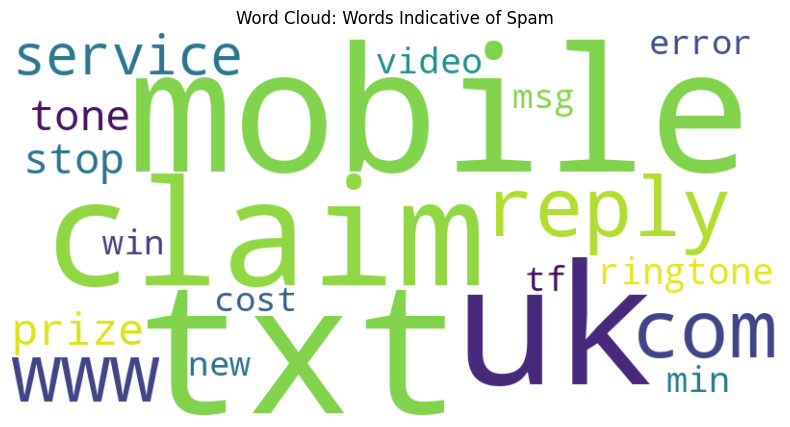

In [33]:
from wordcloud import WordCloud
# Create frequency dictionary for spam words
spam_freq = dict(
    zip(top_spam_words["word"], top_spam_words["weight"])
)

# Generate word cloud
spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(spam_freq)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(spam_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Words Indicative of Spam")
plt.show()

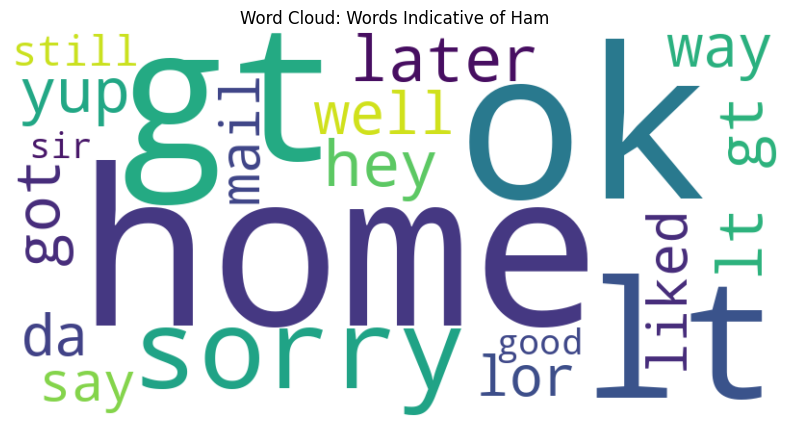

In [34]:
# Create frequency dictionary for ham words
ham_freq = dict(
    zip(top_ham_words["word"], abs(top_ham_words["weight"]))
)

# Generate word cloud
ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(ham_freq)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(ham_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Words Indicative of Ham")
plt.show()

In [35]:
def predict_spam_ham(sentence):

    prediction = best_model.predict([sentence])[0]
    return prediction

In [43]:
predict_spam_ham("Mobile warrenty")

'spam'